##  Detecting AI vs Human-Generated Images

### Can Machines Learn to Spot Other Machines?

Artificial intelligence is now capable of creating stunningly realistic images — from faces that don’t exist to entire scenes generated out of thin air. While this progress is exciting, it also brings a serious challenge: **how can we tell what’s real and what’s not?**

In this notebook, we take on that challenge by building a model that can **distinguish AI-generated images from real, human-created ones**. The goal isn’t just about classification accuracy — it’s about **understanding visual authenticity** in the age of generative AI.

---

###  What This Project Is About

This notebook is part of a broader effort to build an intelligent system that can help verify the trustworthiness of online content. Here, we focus on the **visual** side — teaching a model to recognize the subtle cues that separate real photography from images made by algorithms.

We'll go through the full process:

1. **Exploring the dataset** — understanding what AI vs human images actually look like.
2. **Preprocessing and augmentation** — preparing our data so the model learns from variety, not noise.
3. **Model training** — experimenting with convolutional neural networks (CNNs) and lightweight architectures to detect synthetic artifacts.
4. **Evaluation and insights** — analyzing how well the model generalizes and what features it relies on.

---

###  Dataset Overview

We’ll use the dataset from the **[Kaggle competition: Detect AI vs Human Generated Images](https://www.kaggle.com/competitions/detect-ai-vs-human-generated-images/data)**.
Each entry includes:

| Column      | Description                                             |
| :---------- | :------------------------------------------------------ |
| `file_name` | Path to the image file (e.g., `train_data/example.jpg`) |
| `label`     | 0 → Human-generated, 1 → AI-generated                   |

The images span a wide range of content — portraits, objects, textures, and random scenes — making it a great training ground for learning **visual differences that humans might not easily notice**.

---

### 🧩 Why It Matters

AI-generated content isn’t inherently bad — but it can be **misused** to create fake media, impersonations, or misinformation. A system that can flag or even just estimate the likelihood that an image is AI-generated can become a **first line of defense** in digital authenticity.

This notebook is one component of a larger “Fake Content Detection” project that also includes:

*  Text-based fake news detection
*  Image authenticity and manipulation detection
*  Emotion and sentiment bias analysis
*  Fact-checking and source credibility scoring

Together, these modules form a **multimodal detection system** designed to make online content verification faster, smarter, and more reliable.


#### Tools

In [1]:
import os
import math
import random
import warnings
from pathlib import Path
from typing import List, Tuple, Optional, Union, Dict, Any

import requests
from io import BytesIO

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset,
    WeightedRandomSampler,
)

import torchvision.transforms as T
from torchvision import transforms
import timm



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Display config

In [2]:
pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')

,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg
...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg


In [3]:
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")

dataset config

In [4]:
DATASET_PATH = os.environ.get("DATASET_PATH", "/kaggle/input/ai-vs-human-generated-dataset")
TRAIN_CSV_FILE = "train.csv"
TEST_CSV_FILE = "test.csv"
IMAGE_ROOT_COL = "file_name"
LABEL_COL = "label"
OUT_DIR = "eda_outputs"
SAMPLE_N = 9                      
FAST_MODE = False                 
MAX_IMAGES_FOR_STATS = 100     


In [5]:
os.makedirs(OUT_DIR, exist_ok=True)
print("DATASET_PATH:", DATASET_PATH)


DATASET_PATH: /kaggle/input/ai-vs-human-generated-dataset


## Explore The Dataset

In [6]:
train_csv_path = Path(DATASET_PATH) / TRAIN_CSV_FILE
test_csv_path = Path(DATASET_PATH) / TEST_CSV_FILE

In [7]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
test_df = test_df.rename(columns={'id': 'file_name'})

In [8]:
train_df

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1
...,...,...,...
79945,79945,train_data/9283b107f6274279b6f15bbe77c523aa.jpg,0
79946,79946,train_data/4c6b17fe6dd743428a45773135a10508.jpg,1
79947,79947,train_data/1ccbf96d04e342fd9f629ad55466b29e.jpg,0
79948,79948,train_data/ff960b55f296445abb3c5f304b52e104.jpg,1


In [9]:
test_df


,file_name
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg
...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg


In [10]:
train_df["full_path"] = train_df[IMAGE_ROOT_COL].apply(lambda p: str(Path(DATASET_PATH) / p))
test_df["full_path"] = test_df[IMAGE_ROOT_COL].apply(lambda p: str(Path(DATASET_PATH) / p))
print("Total records:", len(train_df))
display(train_df.head(8))


Total records: 79950


,Unnamed: 0,file_name,label,full_path
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
5,5,train_data/25ea852f30594bc5915eb929682af429.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...
6,6,train_data/e67085fb6d814cbabe08f978c738f3f7.jpg,1,/kaggle/input/ai-vs-human-generated-dataset/tr...
7,7,train_data/041c36d9269146cdb88e7526e3b91651.jpg,0,/kaggle/input/ai-vs-human-generated-dataset/tr...


In [11]:
counts = train_df[LABEL_COL].value_counts().sort_index()
print("\nClass counts:")
print(counts)



Class counts:
label
0    39975
1    39975
Name: count, dtype: int64


In [12]:
display(counts / counts.sum())

label
0    0.5
1    0.5
Name: count, dtype: float64

Helpers functions for plotting

In [13]:
def open_rgb(path: str) -> Image.Image:
    img = Image.open(path)
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img

def show_sample_grid(image_paths: List[str], labels: List[int], title: str, ncols: int = 3):
    n = len(image_paths)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n:]:
        ax.axis("off")
    for i, (p, lbl) in enumerate(zip(image_paths, labels)):
        try:
            img = open_rgb(p)
            axes[i].imshow(img)
            axes[i].set_title(f"{Path(p).name}\nlabel={lbl}", fontsize=9)
            axes[i].axis("off")
        except Exception as e:
            axes[i].text(0.5, 0.5, "ERR", ha="center")
            axes[i].set_title(f"err: {e}", fontsize=8)
            axes[i].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


Show sample images for each class

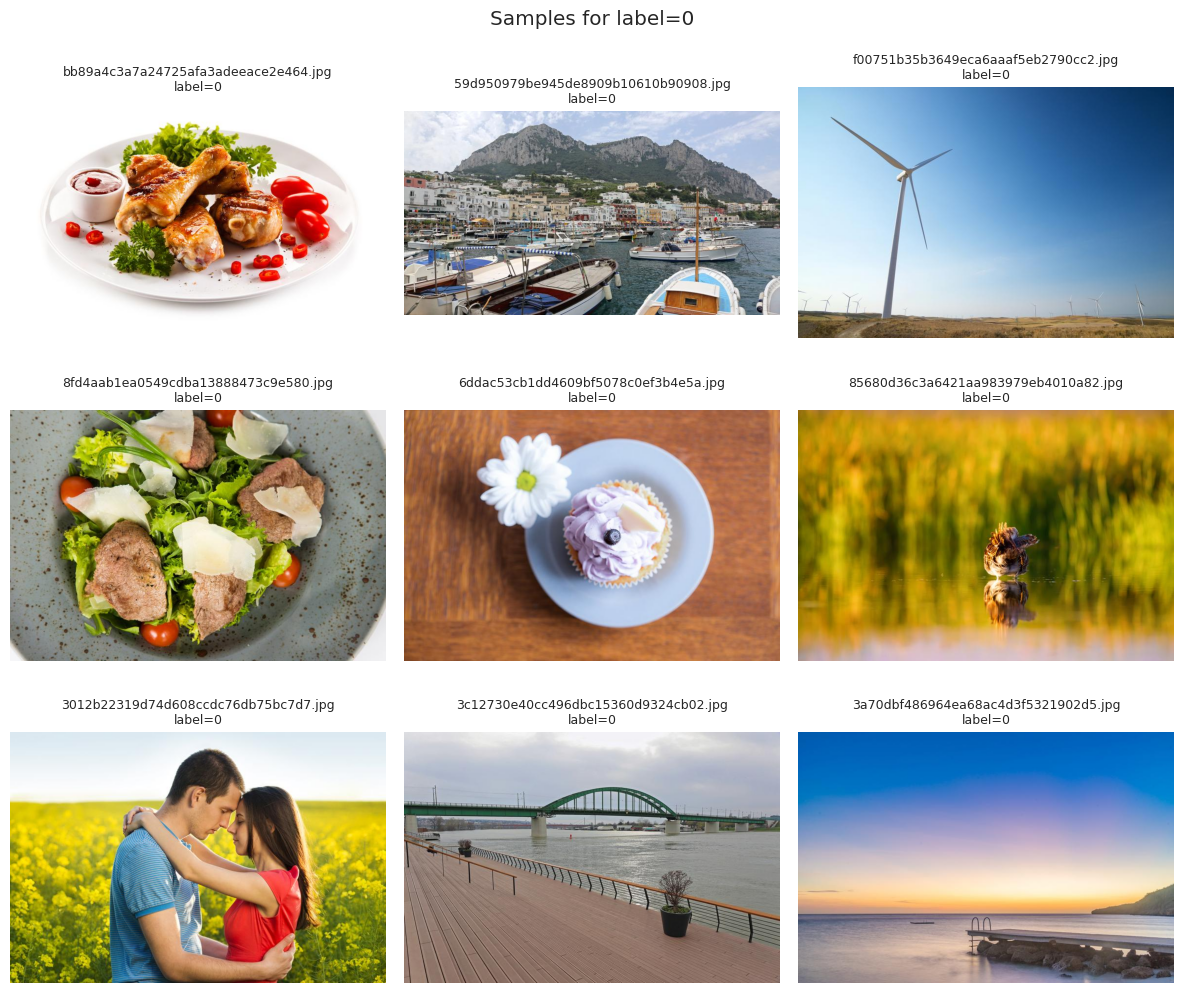

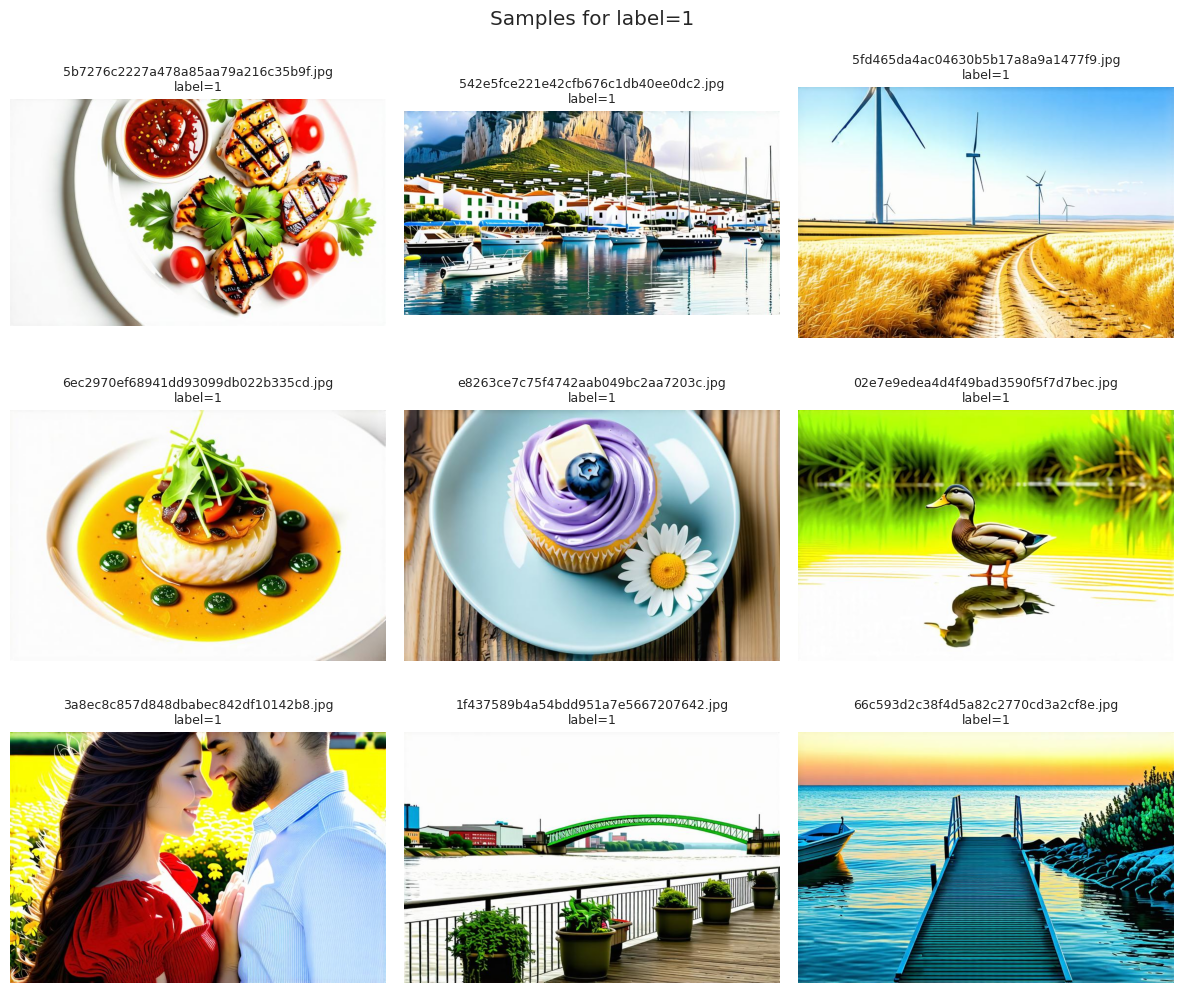

In [14]:
for label in sorted(train_df[LABEL_COL].unique()):
    sample_df = train_df[train_df[LABEL_COL] == label].sample(min(SAMPLE_N, len(train_df[train_df[LABEL_COL] == label])), random_state=42)
    show_sample_grid(sample_df["full_path"].tolist(), sample_df[LABEL_COL].tolist(), title=f"Samples for label={label}", ncols=3)


Class balance plot

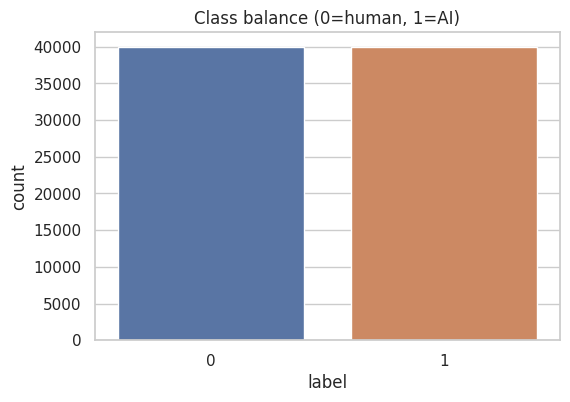

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x=LABEL_COL, data=train_df)
plt.title("Class balance (0=human, 1=AI)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()


## Preprocessing and augmentatio

For Reproducibility

In [16]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

Related Config

In [17]:
INPUT_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4 


Apply Transformations using ImageNet normalization

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Helper function for augmentations and transforms

In [19]:
def get_transforms(
    input_size: int = INPUT_SIZE,
    train: bool = True,
    augment: bool = True,
    small_aug_strength: bool = False
) -> T.Compose:
    """
    Return torchvision transforms for train/val/test.
    - If train & augment=True: includes augmentations
    - If not train: only deterministic center-crop / resize + normalization
    """
    if train and augment:
        # augmentations that work on PIL images
        aug_list = [
            T.RandomResizedCrop(input_size, scale=(0.80, 1.0), ratio=(0.9, 1.1)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
        ]
        if not small_aug_strength:
            aug_list.append(T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)))

        # main transform pipeline
        transform = T.Compose(
            aug_list + [
                T.CenterCrop(input_size) if input_size < 256 else T.Resize((input_size, input_size)),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                T.RandomErasing(p=0.2, scale=(0.01, 0.05), ratio=(0.3, 3.3)),
            ]
        )
    else:
        transform = T.Compose([
            T.Resize(int(input_size * 1.14)),
            T.CenterCrop(input_size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    return transform


Dataset class

In [20]:
class AIDetectDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: Optional[T.Compose] = None, image_root: Path = DATASET_PATH):
        """
        df must contain a column IMAGE_ROOT_COL (relative path) and LABEL_COL
        We also expect df['full_path'] precomputed OR compute here on the fly.
        """
        self.df = df.reset_index(drop=True).copy()
        # try use full_path if present, otherwise build it
        if "full_path" not in self.df.columns:
            self.df["full_path"] = self.df[IMAGE_ROOT_COL].apply(lambda p: str(image_root / p))
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["full_path"]
        label = int(row[LABEL_COL])
        # load image via PIL
        img = Image.open(img_path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


create stratified train/val split and dataloaders

In [21]:
def make_dataloaders(
    df: pd.DataFrame,
    dataset_root: Union[str, Path] = DATASET_PATH,
    test_df: Optional[pd.DataFrame] = None,
    test_csv_path: Optional[Union[str, Path]] = None,
    batch_size: int = BATCH_SIZE,
    val_size: float = 0.15,
    test_size: float = 0.0,
    input_size: int = INPUT_SIZE,
    num_workers: int = NUM_WORKERS,
    oversample: bool = False,
) -> Tuple[DataLoader, DataLoader, Optional[DataLoader]]:
    """
    Create stratified train/val/(optional) test dataloaders.

    - If `test_df` or `test_csv_path` is provided, uses that as the test set.
    - Else if test_size > 0, performs a stratified split to produce a test set.
    - Else no test loader is returned (None).

    Returns (train_loader, val_loader, test_loader_or_None).
    """
    dataset_root = Path(dataset_root)

    # Defensive copy
    df = df.copy().reset_index(drop=True)

    # Ensure full_path is available in dfs
    def _ensure_full_path(dframe: pd.DataFrame) -> pd.DataFrame:
        d = dframe.copy()
        if "full_path" not in d.columns:
            d["full_path"] = d[IMAGE_ROOT_COL].apply(lambda p: str(dataset_root / p))
        return d

    df = _ensure_full_path(df)

    # load provided test csv/df if requested
    provided_test = None
    if test_csv_path is not None:
        test_csv_path = Path(test_csv_path)
        test_df_loaded = pd.read_csv(test_csv_path)
        provided_test = _ensure_full_path(test_df_loaded)
    elif test_df is not None:
        provided_test = _ensure_full_path(test_df.copy().reset_index(drop=True))

    # If user provided an external test set -> only split df into train/val
    if provided_test is not None:
        # stratified train/val split from df (no test carved out)
        splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=RANDOM_SEED)
        train_idx, val_idx = next(splitter.split(df, df[LABEL_COL]))
        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_val = df.iloc[val_idx].reset_index(drop=True)
        df_test = provided_test  # use provided
    else:
        # possibly carve out test from df first (if test_size > 0)
        if test_size > 0.0:
            # First split out test set
            test_splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
            non_test_idx, test_idx = next(test_splitter.split(df, df[LABEL_COL]))
            df_non_test = df.iloc[non_test_idx].reset_index(drop=True)
            df_test = df.iloc[test_idx].reset_index(drop=True)

            # Now split df_non_test into train/val with proportion val_size / (1 - test_size)
            adj_val_size = val_size / max(1e-9, (1.0 - test_size))
            splitter = StratifiedShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
            train_idx, val_idx = next(splitter.split(df_non_test, df_non_test[LABEL_COL]))
            df_train = df_non_test.iloc[train_idx].reset_index(drop=True)
            df_val = df_non_test.iloc[val_idx].reset_index(drop=True)
        else:
            # No external test and no carved test => just train/val split
            splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=RANDOM_SEED)
            train_idx, val_idx = next(splitter.split(df, df[LABEL_COL]))
            df_train = df.iloc[train_idx].reset_index(drop=True)
            df_val = df.iloc[val_idx].reset_index(drop=True)
            df_test = None

    # Build transforms (keep augmentations for train)
    train_transform = get_transforms(input_size=input_size, train=True, augment=True)
    val_transform = get_transforms(input_size=input_size, train=False, augment=False)
    test_transform = get_transforms(input_size=input_size, train=False, augment=False)

    # Build datasets (AIDetectDataset will construct full_path if needed)
    ds_train = AIDetectDataset(df_train, transform=train_transform, image_root=dataset_root)
    ds_val = AIDetectDataset(df_val, transform=val_transform, image_root=dataset_root)
    ds_test = AIDetectDataset(df_test, transform=test_transform, image_root=dataset_root) if df_test is not None else None

    # Train DataLoader with optional oversampling
    if oversample:
        labels = df_train[LABEL_COL].values
        class_counts = np.bincount(labels)
        # In case of more than 2 classes or empty class: protect
        class_weights = np.array([1.0 / (c + 1e-9) for c in class_counts])
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        train_loader = DataLoader(ds_train, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True)
    else:
        train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True) if ds_test is not None else None

    return train_loader, val_loader, test_loader


create dataloaders

In [22]:
train_loader, val_loader, test_loader = make_dataloaders(train_df, test_df=test_df)

In [23]:
print("Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))

Train batches: 2124 Val batches: 375 Test batches: 174


## Model training

Training config

In [24]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 3
LR = 1e-4
BATCH_SIZE = 16

Function to create the model

In [25]:
def load_efficientnet_b3(num_classes: int = 1):
    """Load pretrained EfficientNet-B3 and adapt it for binary classification."""
    model = timm.create_model("efficientnet_b3", pretrained=True)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

Trainer

In [26]:
class Trainer:
    """Handles training, validation, and checkpoint saving."""

    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.Optimizer,
        loss_fn: nn.Module,
        device: str = DEVICE,
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device
        self.evaluator = Evaluator(self.model, device)
        self.best_auc = 0.0

    def train_one_epoch(self, epoch: int):
        """Train the model for one epoch."""
        self.model.train()
        running_loss = 0.0
        progress = tqdm(self.train_loader, desc=f"Epoch {epoch+1}", leave=False)

        for imgs, labels in progress:
            imgs, labels = imgs.to(self.device), labels.to(self.device).float().unsqueeze(1)

            self.optimizer.zero_grad()
            outputs = self.model(imgs)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            progress.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(self.train_loader.dataset)
        return avg_loss

    def fit(self, epochs: int = EPOCHS):
        """Train and validate the model."""
        for epoch in range(epochs):
            train_loss = self.train_one_epoch(epoch)
            metrics = self.evaluator.evaluate(self.val_loader, self.loss_fn)

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {metrics['val_loss']:.4f} | "
                f"Acc: {metrics['val_acc']:.4f} | "
                f"AUC: {metrics['val_auc']:.4f} | "
                f"Prec: {metrics['val_precision']:.4f} | "
                f"Rec: {metrics['val_recall']:.4f} | "
                f"F1: {metrics['val_f1']:.4f}"
            )

            # Save best model
            if metrics["val_auc"] > self.best_auc:
                self.best_auc = metrics["val_auc"]
                torch.save(self.model.state_dict(), "best_model.pth")
                print("✅ Best model updated!")


Evaluator

In [27]:
class Evaluator:
    """Handles validation/testing and metric computation."""

    def __init__(self, model: nn.Module, device: str = DEVICE):
        self.model = model
        self.device = device

    def evaluate(self, dataloader: DataLoader, loss_fn: nn.Module) -> dict:
        """Evaluate model and compute metrics."""
        self.model.eval()
        val_loss = 0.0
        preds, targets = [], []

        with torch.no_grad():
            for imgs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
                imgs, labels = imgs.to(self.device), labels.to(self.device).float().unsqueeze(1)
                outputs = self.model(imgs)
                loss = loss_fn(outputs, labels)
                val_loss += loss.item() * imgs.size(0)

                preds.extend(torch.sigmoid(outputs).cpu().numpy())
                targets.extend(labels.cpu().numpy())

        preds = np.array(preds).flatten()
        targets = np.array(targets).flatten()
        binary_preds = (preds > 0.5).astype(int)

        # Compute metrics
        acc = accuracy_score(targets, binary_preds)
        precision = precision_score(targets, binary_preds, zero_division=0)
        recall = recall_score(targets, binary_preds, zero_division=0)
        f1 = f1_score(targets, binary_preds, zero_division=0)
        try:
            auc = roc_auc_score(targets, preds)
        except ValueError:
            auc = float("nan")

        return {
            "val_loss": val_loss / len(dataloader.dataset),
            "val_acc": acc,
            "val_auc": auc,
            "val_precision": precision,
            "val_recall": recall,
            "val_f1": f1,
        }

Start Training

In [28]:
model = load_efficientnet_b3()
optimizer = optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.BCEWithLogitsLoss()

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [29]:
trainer = Trainer(model, train_loader, val_loader, optimizer, loss_fn)
trainer.fit(epochs=EPOCHS)


Epoch 1:   0%|          | 0/2124 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 0.0968 | Val Loss: 0.0504 | Acc: 0.9824 | AUC: 0.9984 | Prec: 0.9760 | Rec: 0.9892 | F1: 0.9825
✅ Best model updated!


Epoch 2:   0%|          | 0/2124 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.0309 | Val Loss: 0.0360 | Acc: 0.9874 | AUC: 0.9992 | Prec: 0.9820 | Rec: 0.9930 | F1: 0.9875
✅ Best model updated!


Epoch 3:   0%|          | 0/2124 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f14da509260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
        Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7f14da509260>Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
     self._shutdown_workers()
   File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
^^    ^if w.is_alive():^
 ^ ^ ^^  ^^ ^ ^^^^^^^^^^^^^^

Evaluating:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.0193 | Val Loss: 0.0459 | Acc: 0.9829 | AUC: 0.9994 | Prec: 0.9707 | Rec: 0.9958 | F1: 0.9831
✅ Best model updated!


## Save The Model

In [30]:
torch.save(model, "efficientnet_b3_full_ai_image_classifier.pt")
print("✅ Full model saved")


✅ Full model saved


## Test The Model on an image using url

In [31]:
IMG_URL = "https://miro.medium.com/v2/1*LqClB-Wa__W9WrNqP74I3Q.jpeg"

In [32]:
test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Helpers Functions

In [33]:
def load_image_from_url(url: str):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return test_transform(img).unsqueeze(0)  # shape: (1, 3, 300, 300)


def predict(model, img_tensor):
    with torch.no_grad():
        outputs = model(img_tensor.to(DEVICE))
        probs = torch.sigmoid(outputs)
        prob = probs.item()
        label = "AI-generated" if prob >= 0.5 else "Real"
    return label, prob


In [34]:
img_tensor = load_image_from_url(IMG_URL)
label, prob = predict(model, img_tensor)
print(f"🧠 Prediction: {label}")


🧠 Prediction: AI-generated
